# HealthGuard AI: Exploratory Data Analysis (EDA)

**Dataset**: Patient Clinical Readmission Dataset (10,000 Patient Records, 15 Features)  
**Objective**: Perform statistical exploration, patient demographic distribution analysis, comorbidity impact mapping, and clinical feature correlations for 30-day hospital readmission.

---

## 1. Environment Setup & Data Ingestion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

dataset_path = Path('../data/readmission_dataset.csv')
df_raw = pd.read_csv(dataset_path)
print(f"Raw Dataset Loaded: {df_raw.shape[0]} patient records, {df_raw.shape[1]} columns.")
df_raw.head()

Raw Dataset Loaded: 10000 patient records, 15 columns.


,patient_id,age,gender,admission_type,primary_diagnosis_code,num_prior_admissions,time_in_hospital,num_lab_procedures,num_medications,has_comorbidity,discharge_disposition,insurance_type,hospital_id,readmitted_within_30days,days_to_readmission
0,1,75,Other,Emergency,E11,0,5,88.0,35.0,1,Home,Medicare,5,1,7.0
1,2,72,Female,Elective,J45,0,6,46.0,24.0,0,Rehabilitation,Private,5,0,NaN
2,3,73,Female,Urgent,J45,0,3,22.0,3.0,0,Transfer,Private,3,0,NaN
3,4,61,Male,Elective,G47,0,4,14.0,4.0,1,Rehabilitation,Private,6,0,NaN
4,5,87,Female,Urgent,N39,3,6,35.0,28.0,1,Home,Private,3,1,9.0


## 2. Statistical Summary & Target Readmission Rate

In [2]:
print("--- DATASET SUMMARY STATISTICS ---")
display(df_raw.describe())

readmission_rate = df_raw['readmitted_within_30days'].mean() * 100
print(f"Overall 30-Day Hospital Readmission Rate: {readmission_rate:.2f}%")

--- DATASET SUMMARY STATISTICS ---


,patient_id,age,num_prior_admissions,time_in_hospital,num_lab_procedures,num_medications,has_comorbidity,hospital_id,readmitted_within_30days,days_to_readmission
count,10000.00000,10000.000000,10000.000000,10000.000000,9865.000000,9836.000000,10000.000000,10000.000000,10000.000000,2707.000000
mean,5000.50000,69.484300,1.023800,4.984200,50.421085,25.504372,0.415800,3.968100,0.270700,15.267085
std,2886.89568,11.253107,1.247553,2.213332,28.973928,14.558107,0.492884,1.994412,0.444344,8.643979
min,1.00000,28.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000
25%,2500.75000,62.000000,0.000000,3.000000,26.000000,13.000000,0.000000,2.000000,0.000000,8.000000
50%,5000.50000,71.000000,1.000000,5.000000,50.000000,25.000000,0.000000,4.000000,0.000000,15.000000
75%,7500.25000,78.000000,2.000000,6.000000,76.000000,38.000000,1.000000,6.000000,1.000000,23.000000
max,10000.00000,90.000000,5.000000,20.000000,100.000000,50.000000,1.000000,7.000000,1.000000,30.000000


Overall 30-Day Hospital Readmission Rate: 27.07%


## 3. Patient Demographic & Clinical Feature Distributions

C:\Users\SWIFT LITE 14\AppData\Local\Temp\ipykernel_12564\733347208.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_raw, x='num_prior_admissions', y='readmitted_within_30days', ax=axes[1, 0], palette='magma')


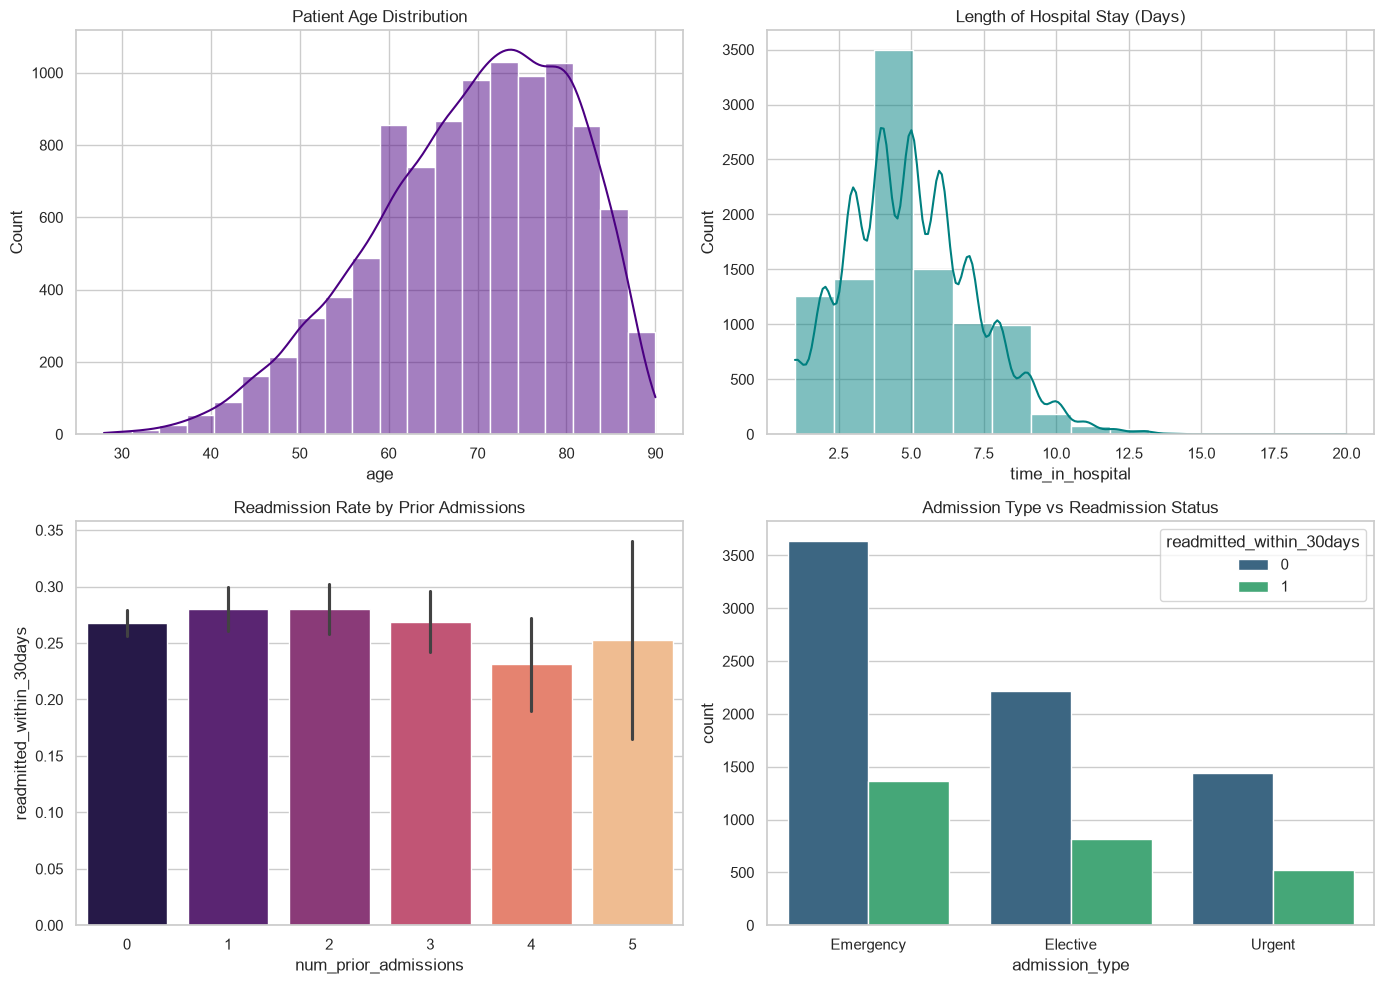

In [3]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age Distribution
sns.histplot(df_raw['age'], kde=True, ax=axes[0, 0], color='indigo', bins=20)
axes[0, 0].set_title('Patient Age Distribution')

# Time in Hospital Distribution
sns.histplot(df_raw['time_in_hospital'], kde=True, ax=axes[0, 1], color='teal', bins=14)
axes[0, 1].set_title('Length of Hospital Stay (Days)')

# Prior Admissions vs Readmission Rate
sns.barplot(data=df_raw, x='num_prior_admissions', y='readmitted_within_30days', ax=axes[1, 0], palette='magma')
axes[1, 0].set_title('Readmission Rate by Prior Admissions')

# Admission Type Count
sns.countplot(data=df_raw, x='admission_type', hue='readmitted_within_30days', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Admission Type vs Readmission Status')

plt.tight_layout()
plt.show()

## 4. Correlation Analysis & Feature Interactions

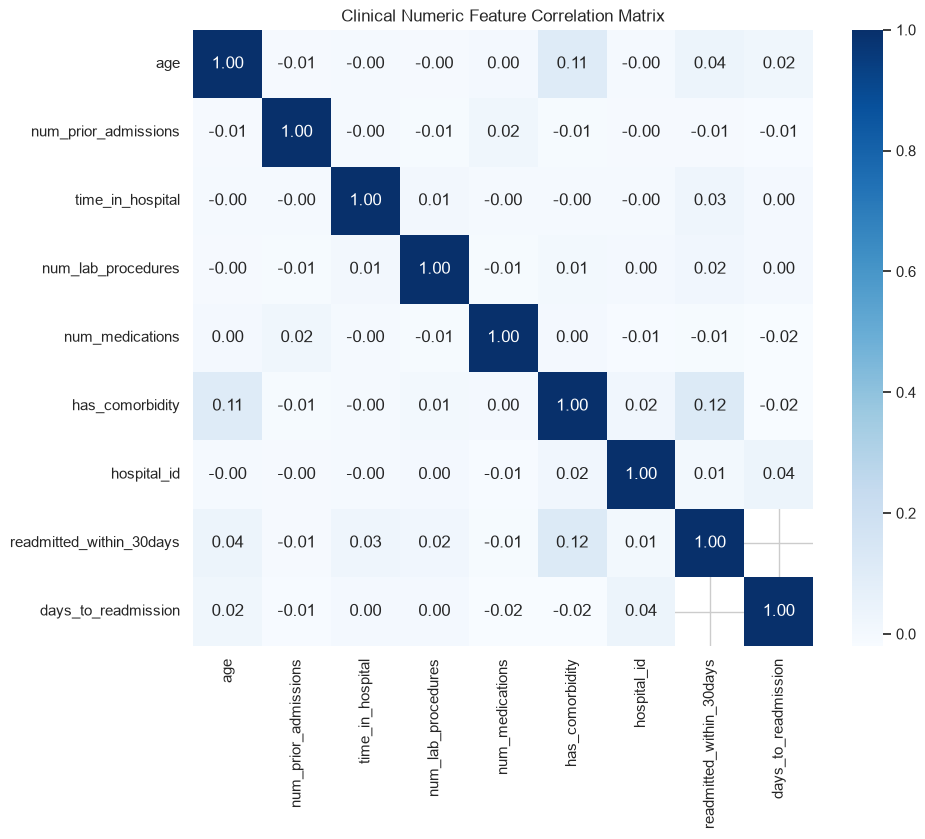

In [4]:
num_df = df_raw.select_dtypes(include=[np.number]).drop(columns=['patient_id'], errors='ignore')
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Clinical Numeric Feature Correlation Matrix')
plt.show()